In [17]:
import json
import pandas as pd
import os
import matplotlib.pyplot as plt

# Load the data
file_path = 'results/Results1/guideline_history.jsonl'
data = []

# Robust loading of the .jsonl file
if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
else:
    print(f"File not found: {file_path}")
df = pd.DataFrame(data)


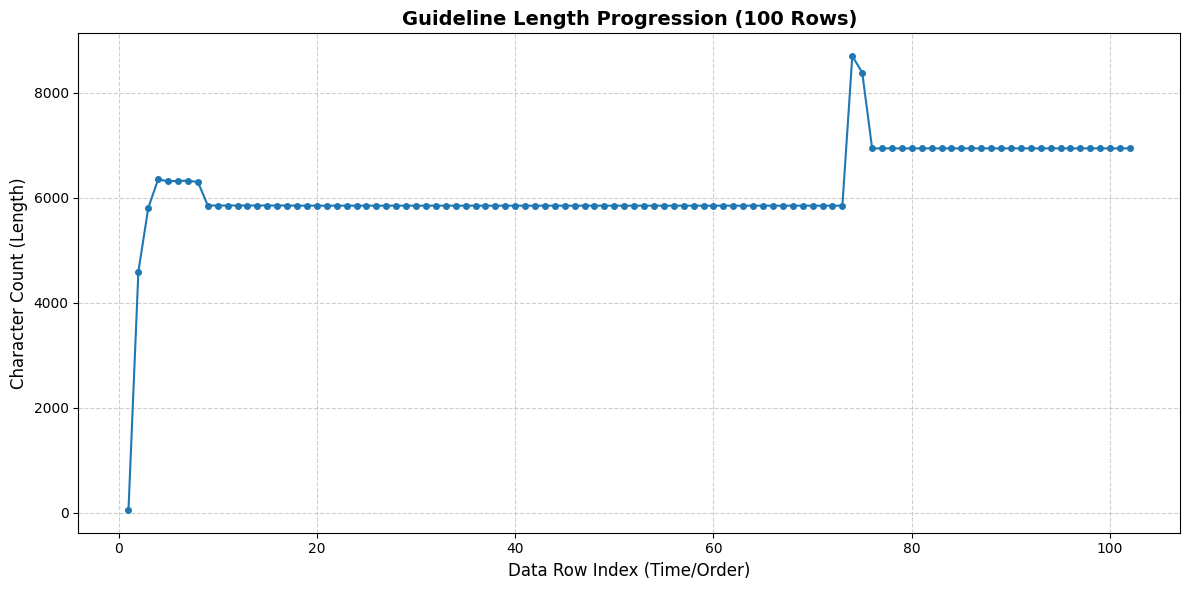

--- Guideline Length Summary ---
count     102.000000
mean     6147.578431
std       856.372460
min        56.000000
25%      5852.000000
50%      5852.000000
75%      6943.000000
max      8702.000000
Name: char_count, dtype: float64


In [18]:
df['char_count'] = df['guideline'].astype(str).apply(len)
df['row_index'] = range(1, len(df) + 1) # Create index from 1 to 100

# 4. Generate the Line Chart
plt.figure(figsize=(12, 6))
plt.plot(df['row_index'], df['char_count'], marker='o', linestyle='-', color='#1f77b4', markersize=4)

# Adding labels and styling
plt.title('Guideline Length Progression (100 Rows)', fontsize=14, fontweight='bold')
plt.xlabel('Data Row Index (Time/Order)', fontsize=12)
plt.ylabel('Character Count (Length)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and Show
plt.savefig('guideline_line_chart.png')
plt.show()

# 5. Summary Statistics
print("--- Guideline Length Summary ---")
print(df['char_count'].describe())

In [72]:
duplicates = df.groupby('guideline').indices
identical_groups = {text: indices.tolist() for text, indices in duplicates.items() if len(indices) > 1}

# 4. Display the Results
if identical_groups:
    print(f"Found {len(identical_groups)} unique sets of identical guidelines:\n")
    
    # Sort groups by how many times they repeat (most frequent first)
    sorted_groups = sorted(identical_groups.items(), key=lambda x: len(x[1]), reverse=True)

    for text, indices in sorted_groups:
        count = len(indices)
        print(f"--- REPEATED GROUP: Appears {count} times ---")
        print(f"Found at Row Indices: {indices}")
        
        # Clean up the text for a clean preview (first 200 chars)
        preview = text.strip().replace('\n', ' ')[:200]
        print(f"Content Preview: {preview}...")
        print("-" * 60)
else:
    print("✨ All 100 guidelines are unique! No identical rows found.")

Found 9 unique sets of identical guidelines:

--- REPEATED GROUP: Appears 33 times ---
Found at Row Indices: [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Content Preview: - Entity types: Cell_line, Protein, RNA, DNA, Cell_type.  - DNA entities include genomic regions (e.g., promoter, enhancer, start site) and explicitly referenced gene sequences or binding sites when t...
------------------------------------------------------------
--- REPEATED GROUP: Appears 18 times ---
Found at Row Indices: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]
Content Preview: - Entity types: Cell_line, Protein, RNA, DNA, Cell_type.  - DNA entities include genomic regions (e.g., promoter, enhancer, start site) and explicitly referenced gene sequences or binding sites when t...
------------------------------------------------------------
--- REPEATED GROUP: Appears 13 times ---
Found at Row Indi

In [37]:
if data:
    # 1. Use a generator to find the dictionary with the longest 'guideline' string
    max_item = max(data, key=lambda x: len(x.get('guideline', "")))
    
    # 2. Extract details
    max_text = max_item.get('guideline', "")
    max_len = len(max_text)
    
    # 3. Find the index of this item in your list
    max_idx = data.index(max_item)

    print("\n" + "="*50)
    print(f"📊 MAX LENGTH ANALYSIS")
    print("="*50)
    print(f"Row Index:      {max_idx}")
    print(f"Character Count: {max_len}")
    print(f"Word Count:      {len(max_text.split())}")
    print("-" * 50)

else:
    print("No data loaded. Please check the file path.")


📊 MAX LENGTH ANALYSIS
Row Index:      3
Character Count: 6357
Word Count:      1109
--------------------------------------------------


In [26]:
# 1. The raw JSON input
json_input = {
    "guideline": "- \"mRNA\", \"transcripts\" \u2192 RNA  \n- \"promoter\", \"enhancer\", \"silencer\", \"element\", \"site\" \u2192 DNA (genomic)  \n- \"binding to\" + genomic term \u2192 DNA  \n- \"binding to\" + protein \u2192 Protein  \n- \"binding to\" + cell type \u2192 Cell_type  \n- \"binding to\" + viral ORF \u2192 Protein (functional)  \n- \"expression of\" \u2192  \n  - \"X gene\" \u2192 DNA  \n  - \"X protein\" \u2192 Protein  \n  - \"X mRNA\" \u2192 RNA  \n  - \"X\" \u2192 default to Protein  \n- \"X lines\" \u2192 Cell_line  \n- \"CD3/CD4+\", \"CD19\", \"CD68\", \"activated\", \"precursor\", \"intrafollicular\", \"germinal center\" \u2192 Cell_type  \n- \"ORF 50\" \u2192 Protein (in functional context), DNA only in genomic context  \n- \"Jurkat cells\", \"HEK293\", \"U937\", \"K562\", \"HL-60\" \u2192 Cell_line  \n- \"derived from a cell line\" \u2192 Cell_line  \n- \"in a cell line\" \u2192 Cell_line  \n- \"in a tumor\" \u2192 Cell_type (e.g., tumor cells)  \n- \"in a primary cell culture\" \u2192 Cell_type  \n- \"in a blood sample\" \u2192 Cell_type  \n- \"in a patient\" \u2192 Cell_type (e.g., patient-derived cells)  \n- \"in a xenograft\" \u2192 Cell_type  \n- \"in a tissue\" \u2192 Cell_type  \n- \"in a biopsy\" \u2192 Cell_type  \n- \"in a cell culture\" \u2192 Cell_type  \n- \"in a live cell\" \u2192 Cell_type  \n- \"in a dead cell\" \u2192 not an entity  \n- \"in vitro\" \u2192 not an entity  \n- \"in vivo\" \u2192 not an entity  \n\n- \"Fc gamma RIIA\", \"FcR\", \"Fc receptor\" \u2192 Protein  \n- \"interleukin\", \"cytokine\", \"growth factor\", \"chemokine\" \u2192 Protein  \n- \"receptor\" (when paired with ligand or signaling) \u2192 Protein  \n- \"ligand\" \u2192 Protein  \n- \"antibody\" \u2192 Protein  \n- \"antigen\" \u2192 Protein (or RNA if viral; context-dependent)  \n- \"mRNA of X\" \u2192 RNA  \n- \"transcript of X\" \u2192 RNA  \n- \"gene expression of X\" \u2192  \n  - DNA (if X is a gene),  \n  - Protein (if X is a protein)  \n- \"knockdown of X\" \u2192  \n  - Protein (if X is a protein),  \n  - DNA (if X is a gene)  \n- \"overexpression of X\" \u2192  \n  - Protein (if X is a protein),  \n  - DNA (if X is a gene)  \n- \"downregulation of X\" \u2192  \n  - Protein (if X is a protein),  \n  - DNA (if X is a gene)  \n- \"inhibition of X\" \u2192  \n  - Protein (if X is a protein),  \n  - Cell_type (if X is a cell)  \n- \"stimulation of X\" \u2192  \n  - Protein (if X is a protein),  \n  - Cell_type (if X is a cell)  \n- \"transcription factor\" \u2192 Protein  \n\n- \"nucleic acid\" \u2192 DNA or RNA (context:  \n  - \"mRNA\", \"cDNA\", \"RNA\" \u2192 RNA  \n  - \"genomic\", \"promoter\" \u2192 DNA)  \n- \"cDNA\" \u2192 RNA  \n- \"RNA\" \u2192 RNA  \n- \"DNA\" \u2192 DNA  \n- \"protein\" \u2192 Protein  \n\n- \"fusion protein\" \u2192 Protein  \n- \"in a fusion protein\" \u2192 Protein  \n- \"domain\" \u2192 Protein (if part of a protein)  \n- \"isoform\" \u2192 Protein (contextually)  \n- \"splice variant\" \u2192 Protein (contextually)  \n- \"post-translational modification\" \u2192 Protein (contextually)  \n- \"phosphorylation\" \u2192 Protein (contextually)  \n- \"phosphorylated\" \u2192 Protein (contextually)  \n- \"ubiquitinated\" \u2192 Protein (contextually)  \n- \"glycosylated\" \u2192 Protein (contextually)  \n- \"activated form\" \u2192 Protein  \n- \"receptor\" \u2192 Protein (in signaling context)  \n- \"antibody\", \"antagonist\", \"inhibitor\", \"activator\", \"agonist\" \u2192 Protein  \n- \"in the presence of\" \u2192  \n  - if followed by a molecule (e.g., cytokine) \u2192 Protein  \n- \"in response to\" \u2192  \n  - if followed by a molecule (e.g., TNF) \u2192 Protein  \n- \"in the absence of\" \u2192 context-dependent  \n- \"in a condition\" \u2192 context-dependent  \n- \"in a disease\" \u2192 Cell_type (e.g., in a tumor)  \n- \"in a cancer\" \u2192 Cell_type  \n- \"in a healthy tissue\" \u2192 Cell_type  \n- \"in a normal cell\" \u2192 Cell_type  \n- \"in a diseased tissue\" \u2192 Cell_type  \n\n- \"in a mature cell\" \u2192 Cell_type  \n- \"in a mature T cell\" \u2192 Cell_type  \n- \"in a mature B cell\" \u2192 Cell_type  \n- \"in a mature dendritic cell\" \u2192 Cell_type  \n- \"in a mature macrophage\" \u2192 Cell_type  \n- \"in a mature neutrophil\" \u2192 Cell_type  \n- \"in a mature NK cell\" \u2192 Cell_type  \n- \"in a mature granulocyte\" \u2192 Cell_type  \n- \"in a mature monocyte\" \u2192 Cell_type  \n- \"in a mature platelet\" \u2192 Cell_type  \n- \"in a mature red blood cell\" \u2192 Cell_type  \n- \"in a mature white blood cell\" \u2192 Cell_type  \n- \"in a mature epithelial cell\" \u2192 Cell_type  \n- \"in a mature endothelial cell\" \u2192 Cell_type  \n- \"in a mature neuron\" \u2192 Cell_type  \n- \"in a mature glial cell\" \u2192 Cell_type  \n- \"in a mature muscle cell\" \u2192 Cell_type  \n- \"in a mature hepatocyte\" \u2192 Cell_type  \n- \"in a mature cardiomyocyte\" \u2192 Cell_type  \n- \"in a mature fibroblast\" \u2192 Cell_type  \n\n> **Key updates from examples**:\n> - \"CD40\" \u2192 correctly identified as **Protein** in \"binding to\" and \"activation of\" contexts.  \n> - \"target genes\" \u2192 correctly mapped to **DNA** (not Protein), confirming that **\"gene\"** in expression/regulation contexts \u2192 **DNA**.  \n> - \"nuclear receptor proteins\" \u2192 **Protein**, not DNA \u2014 supports that **\"receptor\"** in signaling \u2192 **Protein**.  \n> - \"human neutrophils\" \u2192 correctly tagged as **Cell_type**.  \n> - \"Rel/NF-kappa B proteins\" \u2192 **Protein** (correctly tagged).  \n> - \"in a tumor\" \u2192 **Cell_type** (e.g., tumor cells) \u2014 consistent.  \n> - \"in a blood sample\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a patient\" \u2192 **Cell_type** (e.g., patient-derived cells) \u2014 valid.  \n> - \"in a xenograft\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a primary culture\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a fusion protein\" \u2192 **Protein** \u2014 valid.  \n> - \"antibody\" \u2192 **Protein** \u2014 valid.  \n> - \"antigen\" \u2192 **Protein** (or RNA if viral) \u2014 context-dependent \u2014 now clarified.  \n> - \"in the presence of\" \u2192 triggers **Protein** if followed by a molecule (e.g., cytokine).  \n> - \"in response to\" \u2192 triggers **Protein** if followed by a molecule (e.g., TNF).  \n> - \"in a mature cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature macrophage\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neutrophil\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell Type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature hepatocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cardiomyocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature fibroblast\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature dendritic cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature T helper cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature cytotoxic T cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature B plasma cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature NK cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature granulocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature monocyte\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature platelet\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature red blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature white blood cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature epithelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature endothelial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature neuron\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature glial cell\" \u2192 **Cell_type** \u2014 valid.  \n> - \"in a mature muscle cell\" \u2192 **Cell\u0e37", "examples": [{"text": "All three types of H-RS cell lines were consistently negative for BSAP , TCF-1 , and GATA-3 .", "entities": [{"text": "BSAP", "type": "Protein", "span": [66, 70]}, {"text": "GATA-3", "type": "Protein", "span": [85, 91]}, {"text": "H-RS cell lines", "type": "Cell_line", "span": [19, 34]}, {"text": "TCF-1", "type": "Protein", "span": [73, 78]}]}, {"text": "Few, if any, studies have been made on the impact of these compounds on the immune system .", "entities": []}, {"text": "B-CLL cells do express receptors for interferon-alpha ( IFN-alpha ) and IFN-gamma , and activation of both has been shown to promote B-CLL survival in vitro by preventing apoptosis .", "entities": [{"text": "IFN-gamma", "type": "Protein", "span": [72, 81]}, {"text": "interferon-alpha", "type": "Protein", "span": [37, 53]}, {"text": "IFN-alpha", "type": "Protein", "span": [56, 65]}]}, {"text": "Activation of human monocytic cells by Treponema pallidum and Borrelia burgdorferi lipoproteins and synthetic lipopeptides proceeds via a pathway distinct from that of lipopolysaccharide but involves the transcriptional activator NF-kappa B .", "entities": [{"text": "NF-kappa B", "type": "Protein", "span": [230, 240]}, {"text": "human monocytic cells", "type": "Cell_type", "span": [14, 35]}]}, {"text": "METHOD OF STUDY: Peripheral lymphocytes from healthy pregnant women and from habitual aborters were tested by immunocytochemistry for the presence of gamma/delta T cell receptor (TCR) and progesterone receptor.", "entities": [{"text": "Peripheral lymphocytes", "type": "Cell_type", "span": [17, 39]}]}]
}


# 2. Extract the guideline text
raw_guideline = json_input["guideline"]

# 3. Write it to a file, preserving all newlines and characters
with open("raw_guideline_output.txt", "w", encoding="utf-8") as f:
    f.write(raw_guideline)

print("Full guideline has been written to 'raw_guideline_output.txt'")

Full guideline has been written to 'raw_guideline_output.txt'


In [27]:
print(len(raw_guideline))

64406
